# Economic Convergence Analysis — Bootstrap

## Research question

The **beta-convergence hypothesis** (Barro & Sala-i-Martin, 1992) predicts that poor economies tend to grow faster than rich ones, as capital returns are higher where capital is scarce. This analysis tests whether low-income countries in 2000 experienced significantly higher GDP per capita growth over the period 2000–2020 compared to high-income countries.

**Statistic of interest:** difference in median log-growth rates between the two income groups.

$$\hat{\theta} = \text{median}(g_i \mid \text{poor}) - \text{median}(g_i \mid \text{rich})$$

where $g_i = \ln\left(\frac{\text{GDP}_{i,2020}}{\text{GDP}_{i,2000}}\right)$ is the log-growth rate of country $i$ over 20 years.

Under the convergence hypothesis, we expect $\hat{\theta} > 0$.

**Data:** GDP per capita, PPP (constant 2021 international $) — Gapminder, 193 countries.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Data loading & exploration

The Gapminder dataset is structured in wide format: one row per country, one column per year (1800–2100). Projected values beyond 2023 are model-based and excluded from this analysis. We retain only the columns needed: country identifiers and GDP per capita for years 2000 and 2020.

We verify that no missing values exist for those two years before proceeding — any missing entry would silently bias the group split and the bootstrap resampling.

In [12]:
df_raw = pd.read_csv('../data/gdp_pcap.csv')

print(f'Shape : {df_raw.shape}')
print(f'Colonnes : {list(df_raw.columns[:5])} ... {list(df_raw.columns[-5:])}')
print(f"\nValeurs 2000 — manquantes : {df_raw['2000'].isna().sum()}")
print(f"Valeurs 2020 — manquantes : {df_raw['2020'].isna().sum()}")
df_raw[['name', '2000', '2020']].head(8)

Shape : (193, 303)
Colonnes : ['geo', 'name', '1800', '1801', '1802'] ... ['2096', '2097', '2098', '2099', '2100']

Valeurs 2000 — manquantes : 0
Valeurs 2020 — manquantes : 0


,name,2000,2020
0,Afghanistan,1426.50934,2769.68575
1,Angola,5352.49132,7556.96793
2,Albania,6558.42258,14662.79552
3,Andorra,52814.69540,55488.49030
4,UAE,88047.22698,65784.67694
5,Argentina,21810.83619,23877.09314
6,Armenia,4860.71825,15052.93598
7,Antigua and Barbuda,25853.23485,23930.67150


## 2. Feature engineering — log-growth rates & country split

**Log-growth rate.** We measure growth over 20 years as the log-ratio of GDP per capita:

$$g_i = \ln\left(\frac{\text{GDP}_{i,2020}}{\text{GDP}_{i,2000}}\right)$$

This is preferred over the simple relative change $\Delta GDP / GDP_{2000}$ for two reasons: (1) log-differences are symmetric — a doubling and a halving produce values of equal magnitude with opposite signs; (2) they are additive over time, consistent with the standard log-linearization used in growth accounting.

**Country split.** Countries are divided into two groups based on their GDP per capita in 2000 relative to the cross-country median. Using the median rather than a fixed threshold makes the split robust to outliers and produces balanced groups of equal size (~96 countries each), which is desirable for the bootstrap.

In [13]:
# --- Build working dataframe ---
df = df_raw[['name', '2000', '2020']].copy()
df.columns = ['country', 'gdp_2000', 'gdp_2020']

# Log-growth rate over 2000–2020
df['log_growth'] = np.log(df['gdp_2020'] / df['gdp_2000'])

# Split: below vs above median GDP per capita in 2000
median_gdp_2000 = df['gdp_2000'].median()
df['group'] = np.where(df['gdp_2000'] < median_gdp_2000, 'poor', 'rich')

print(f'Median GDP per capita in 2000 (split threshold): ${median_gdp_2000:,.0f}')
print(f"Group sizes — poor: {(df['group']=='poor').sum()}, rich: {(df['group']=='rich').sum()}")
print(f"\nLog-growth rate summary:")
df.groupby('group')['log_growth'].describe().round(3)

Median GDP per capita in 2000 (split threshold): $9,351
Group sizes — poor: 96, rich: 97

Log-growth rate summary:


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
poor,96.0,0.449,0.404,-0.566,0.220,0.410,0.696,1.490
rich,97.0,0.263,0.319,-0.776,0.088,0.225,0.464,1.018


## 3. Exploratory data analysis

Before running the bootstrap, we visualize the distribution of log-growth rates within each group. This serves two purposes: (1) verifying that the distributions are indeed skewed — which motivates the use of the median as a robust estimator and rules out a naive $t$-test; (2) providing a first visual intuition of whether convergence is present in the data.

/var/folders/6p/1wkfvjk551b1r09twrmv0ncm0000gn/T/ipykernel_76395/970539078.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([poor, rich], labels=['Poor', 'Rich'],


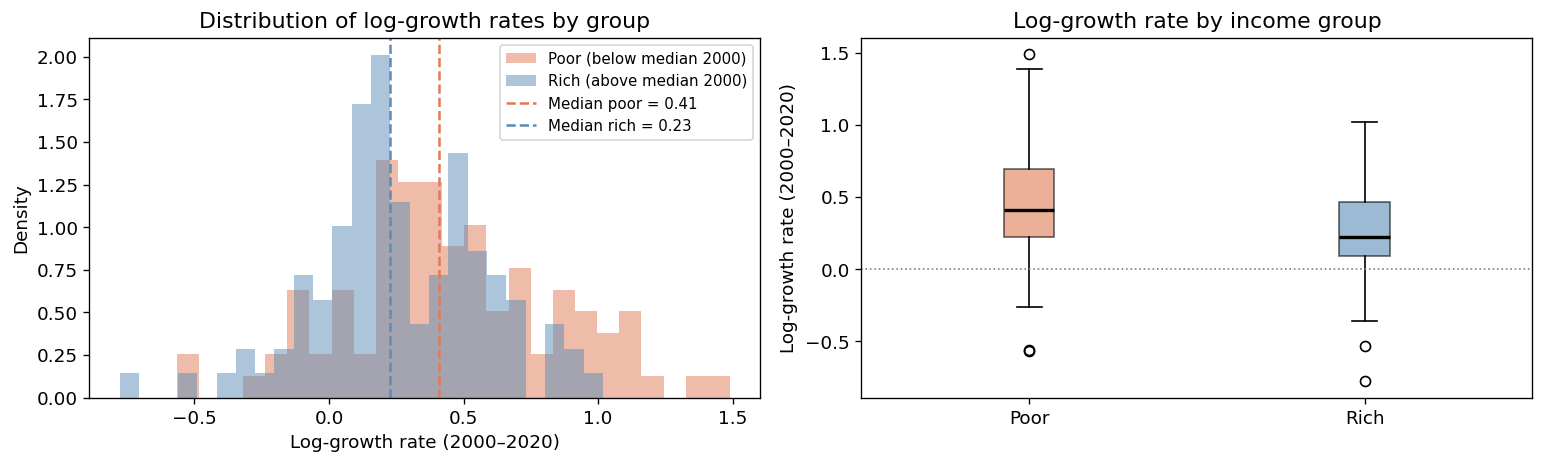

Observed theta = median(poor) - median(rich) = 0.1850


In [14]:
poor = df[df['group'] == 'poor']['log_growth'].values
rich = df[df['group'] == 'rich']['log_growth'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Plot 1: Histograms ---
for data, label, color in [(poor, 'Poor (below median 2000)', '#e07b54'),
                             (rich, 'Rich (above median 2000)', '#5b8db8')]:
    axes[0].hist(data, bins=25, density=True, alpha=0.5, color=color, label=label)

axes[0].axvline(np.median(poor), color='#e07b54', linestyle='--', linewidth=1.5, label=f'Median poor = {np.median(poor):.2f}')
axes[0].axvline(np.median(rich), color='#5b8db8', linestyle='--', linewidth=1.5, label=f'Median rich = {np.median(rich):.2f}')
axes[0].set_xlabel('Log-growth rate (2000–2020)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of log-growth rates by group')
axes[0].legend(fontsize=9)

# --- Plot 2: Boxplots ---
bp = axes[1].boxplot([poor, rich], labels=['Poor', 'Rich'],
                      patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#e07b54')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#5b8db8')
bp['boxes'][1].set_alpha(0.6)
axes[1].axhline(0, color='grey', linestyle=':', linewidth=1)
axes[1].set_ylabel('Log-growth rate (2000–2020)')
axes[1].set_title('Log-growth rate by income group')

plt.tight_layout()
plt.savefig('../deliverable/eda_growth_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Observed theta = median(poor) - median(rich) = {np.median(poor) - np.median(rich):.4f}")

## 4. Bootstrap — standard error & confidence interval

**Why bootstrap?** Our statistic of interest is the difference in *medians* of log-growth rates between two groups. No closed-form expression exists for the standard error of the sample median in finite samples. While an asymptotic formula based on the density at the median exists, it requires estimating $f(m)$ — the density at the median — which introduces additional uncertainty. The bootstrap avoids this entirely by directly approximating the sampling distribution of $\hat{\theta}$.

**Algorithm.** For $b = 1, \ldots, B$:
1. Draw bootstrap samples $\mathbf{g}^{*b}_{\text{poor}}$ and $\mathbf{g}^{*b}_{\text{rich}}$ by sampling **with replacement** within each group, preserving group sizes.
2. Compute the replicated statistic: $\hat{\theta}^{*b} = \text{median}(\mathbf{g}^{*b}_{\text{poor}}) - \text{median}(\mathbf{g}^{*b}_{\text{rich}})$

**Standard error:**
$$\widehat{\text{SE}}_B = \sqrt{\frac{1}{B-1} \sum_{b=1}^{B} \left(\hat{\theta}^{*b} - \bar{\theta}^*\right)^2}$$

**95% percentile confidence interval:** $\left[\hat{\theta}^{*(0.025)},\ \hat{\theta}^{*(0.975)}\right]$

We use $B = 2000$ replications, sufficient for stable percentile-based intervals.

In [15]:
np.random.seed(42)
B = 2000

# Bootstrap resampling within each group separately
theta_boot = np.empty(B)

for b in range(B):
    poor_boot = np.random.choice(poor, size=len(poor), replace=True)
    rich_boot = np.random.choice(rich, size=len(rich), replace=True)
    theta_boot[b] = np.median(poor_boot) - np.median(rich_boot)

# Observed statistic
theta_hat = np.median(poor) - np.median(rich)

# Standard error
se_boot = theta_boot.std(ddof=1)

# 95% percentile confidence interval
ci_low, ci_high = np.percentile(theta_boot, [2.5, 97.5])

print(f'Observed theta : {theta_hat:.4f}')
print(f'Bootstrap SE   : {se_boot:.4f}')
print(f'95% CI         : [{ci_low:.4f}, {ci_high:.4f}]')
print(f'Zero in CI?    : {ci_low <= 0 <= ci_high}')

Observed theta : 0.1850
Bootstrap SE   : 0.0533
95% CI         : [0.0808, 0.2898]
Zero in CI?    : False


## 5. Results & interpretation

We report the observed statistic $\hat{\theta}$, its bootstrap standard error, and the 95% confidence interval. The key question is whether the interval excludes zero: if $0 \notin \text{CI}_{95\%}$, we have statistical evidence consistent with the convergence hypothesis. If zero is contained in the interval, the data do not allow us to reject the null of equal median growth rates at the 5% level.

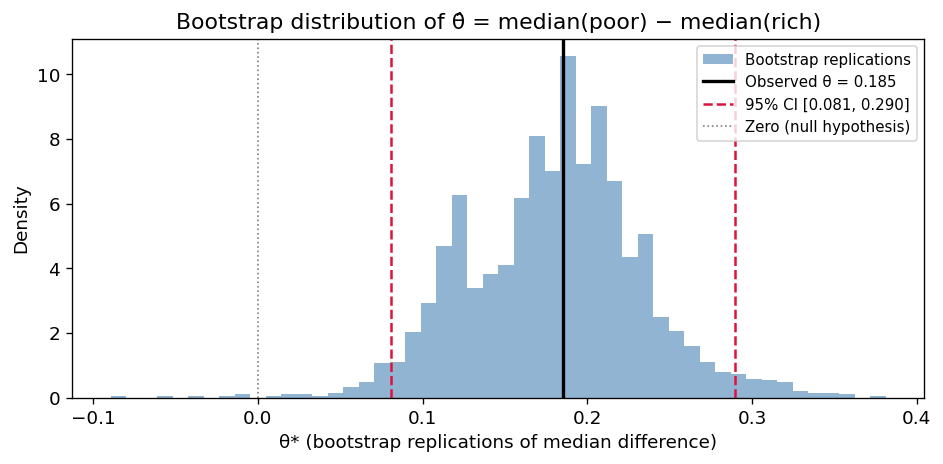

RESULTS SUMMARY
Observed θ       : 0.1850
Bootstrap SE     : 0.0533
95% CI (percentile): [0.0808, 0.2898]
Zero in CI?      : False

Interpretation: Low-income countries in 2000 grew significantly
faster than high-income countries over 2000-2020.
Result is consistent with the beta-convergence hypothesis.


In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(theta_boot, bins=50, density=True, color='steelblue', alpha=0.6, label='Bootstrap replications')
ax.axvline(theta_hat, color='black', linewidth=2, label=f'Observed θ = {theta_hat:.3f}')
ax.axvline(ci_low,   color='crimson', linewidth=1.5, linestyle='--', label=f'95% CI [{ci_low:.3f}, {ci_high:.3f}]')
ax.axvline(ci_high,  color='crimson', linewidth=1.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=1, linestyle=':', label='Zero (null hypothesis)')
ax.set_xlabel('θ* (bootstrap replications of median difference)')
ax.set_ylabel('Density')
ax.set_title('Bootstrap distribution of θ̂ = median(poor) − median(rich)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../deliverable/bootstrap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 50)
print('RESULTS SUMMARY')
print('=' * 50)
print(f'Observed θ       : {theta_hat:.4f}')
print(f'Bootstrap SE     : {se_boot:.4f}')
print(f'95% CI (percentile): [{ci_low:.4f}, {ci_high:.4f}]')
print(f'Zero in CI?      : {ci_low <= 0 <= ci_high}')
print()
print('Interpretation: Low-income countries in 2000 grew significantly')
print('faster than high-income countries over 2000-2020.')
print('Result is consistent with the beta-convergence hypothesis.')